# **Random Forest Regressor**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Garder seulement 3000 lignes aléatoires (sans override de df)
df_scaled = pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
df_small = df_scaled.sample(n=3000, random_state=42)

print(df_small.shape)
df_small.head()

(3000, 29)


,Job_Title,Median_Salary_USD,Experience_Required_Years,Remote_Work_Ratio_%,Automation_Risk_%,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,...,Industry_retail,Industry_transportation,Location_australia,Location_brazil,Location_canada,Location_china,Location_germany,Location_india,Location_uk,Location_usa
2308,research scientist (life sciences),0.905473,-1.658495,0.596680,-0.678304,-1.156028,-0.216828,high_growth,1.134226,-0.684784,...,-0.375195,-0.372821,-0.380954,-0.376696,2.635720,-0.378713,-0.377446,-0.374732,-0.37992,-0.375830
22404,tefl teacher,0.837639,-0.173487,-0.094125,0.831030,0.465449,2.271770,high_growth,0.110340,0.639496,...,-0.375195,-0.372821,-0.380954,-0.376696,-0.379403,-0.378713,-0.377446,-0.374732,-0.37992,2.660774
23397,"editor, magazine features",0.167511,0.816517,-1.230967,-0.097176,-0.902473,-0.177612,high_growth,0.191606,0.706845,...,-0.375195,-0.372821,-0.380954,-0.376696,-0.379403,-0.378713,-0.377446,2.668572,-0.37992,-0.375830
25058,"journalist, magazine",1.443963,-0.338488,0.959517,0.490908,0.311464,-0.274272,decline,0.796400,-0.489038,...,-0.375195,-0.372821,-0.380954,-0.376696,-0.379403,2.640523,-0.377446,-0.374732,-0.37992,-0.375830
2664,"engineer, land",-1.116861,0.816517,-0.541197,1.029956,-1.409004,-0.119884,high_growth,-1.523452,1.247542,...,-0.375195,2.682253,2.624992,-0.376696,-0.379403,-0.378713,-0.377446,-0.374732,-0.37992,-0.375830


**Target Encoding function**

In [4]:
def target_encode(df, column, target):
    """Encode one categorical column using target mean."""
    mean_map = df.groupby(column)[target].mean()
    return df[column].map(mean_map)


**Préparation des données + Target Encoding**

In [5]:
target = "Automation_Risk_%"
X = df_small.drop(columns=[target])
y = df_small[target]

# Identify columns
num_cols = X.select_dtypes(include=["float64","int64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Num cols:", num_cols)
print("Cat cols:", cat_cols)

# Apply target encoding
X_encoded = X.copy()

for col in cat_cols:
    X_encoded[col] = target_encode(df_small, col, target)

# final df contains only numeric values
print("Final encoded shape:", X_encoded.shape)


Num cols: ['Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Job_Value_Index', 'Vulnerability_Index', 'Required_Education_num', 'AI_Impact_Level_num', 'Job_Status_num', 'Industry_education', 'Industry_entertainment', 'Industry_finance', 'Industry_healthcare', 'Industry_it', 'Industry_manufacturing', 'Industry_retail', 'Industry_transportation', 'Location_australia', 'Location_brazil', 'Location_canada', 'Location_china', 'Location_germany', 'Location_india', 'Location_uk', 'Location_usa']
Cat cols: ['Job_Title', 'Growth_Category']
Final encoded shape: (3000, 28)


**Train/Test split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


**Hyperparameter Grid for Random Forestt**

In [7]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters found:\n", grid_search.best_params_)


Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best parameters found:
 {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


**Train the best model**

In [8]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

print("Final Model Performance:")
print("MSE :", mean_squared_error(y_test, pred))
print("R²  :", r2_score(y_test, pred))


Final Model Performance:
MSE : 0.09650780601554354
R²  : 0.9095146031735714


**Feature Importances**

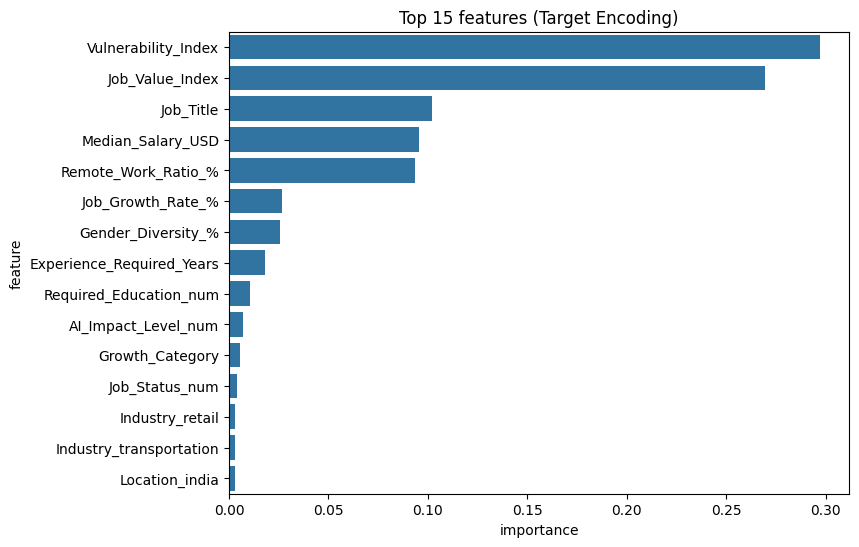

In [9]:
importances = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importances.head(15), x="importance", y="feature")
plt.title("Top 15 features (Target Encoding)")
plt.show()


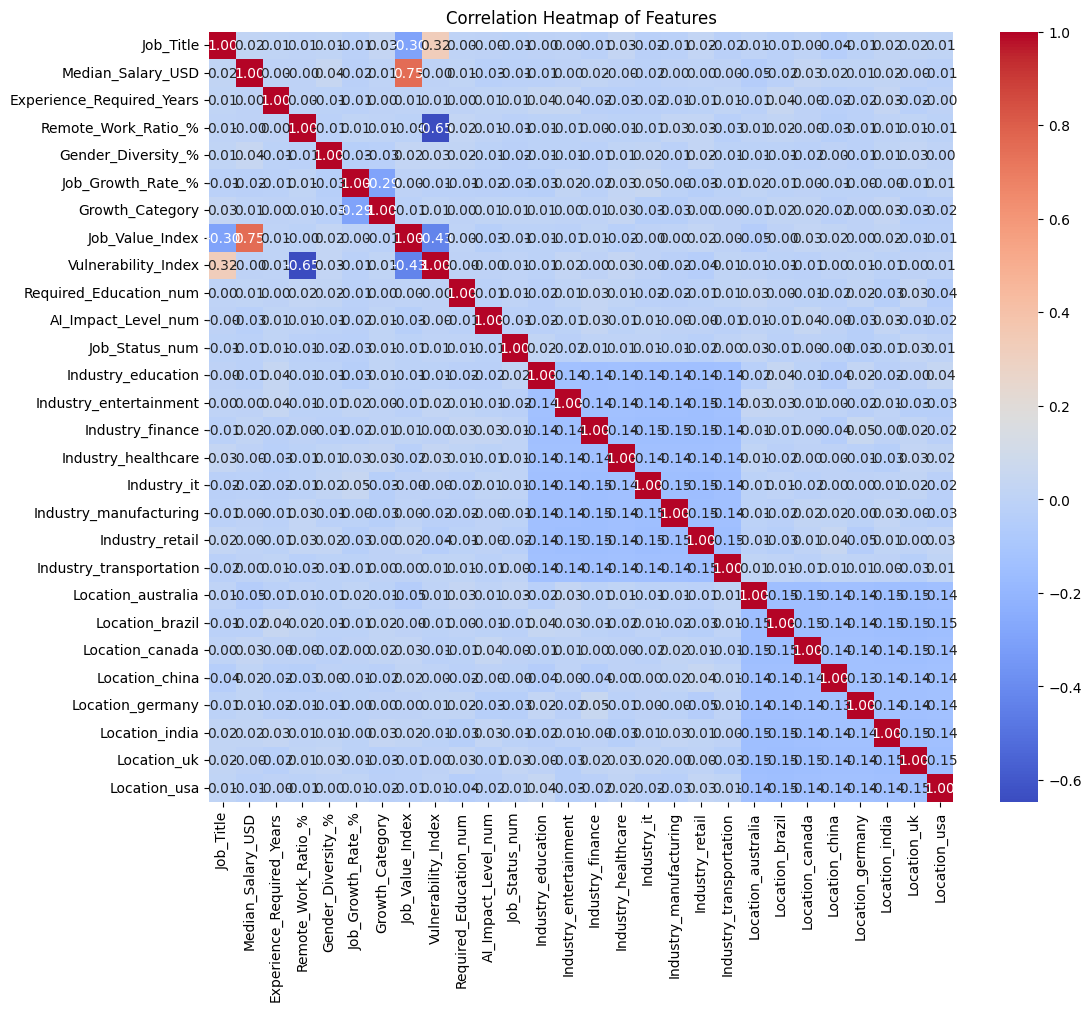

In [10]:
# Correlation matrix
corr_matrix = X_encoded.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Features")
plt.show()


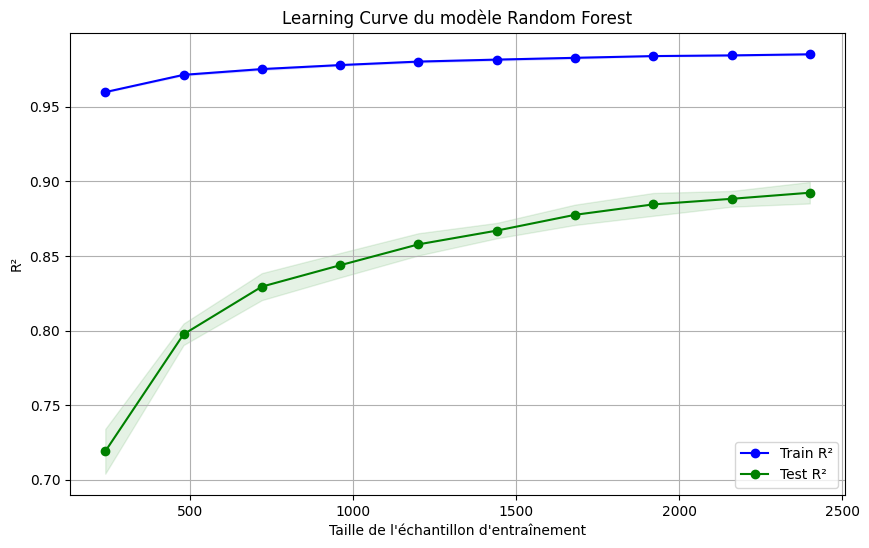

In [11]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_encoded, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Moyennes et écarts types
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Train R²")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Test R²")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("R²")
plt.title("Learning Curve du modèle Random Forest")
plt.legend()
plt.grid(True)
plt.show()


Top 20 métiers les plus à risque :
Job_Title
teacher, adult education                        1.687942
surveyor, minerals                              1.634037
production designer, theatre/television/film    1.503101
immunologist                                    1.385264
multimedia programmer                           1.348168
musician                                        1.334605
therapist, nutritional                          1.320520
exercise physiologist                           1.298089
land/geomatics surveyor                         1.295828
retail banker                                   1.293568
teacher, early years/pre                        1.264007
electronics engineer                            1.212623
jewellery designer                              1.174629
conservator, museum/gallery                     1.173064
adult guidance worker                           1.159675
merchant navy officer                           1.125246
corporate treasurer                        

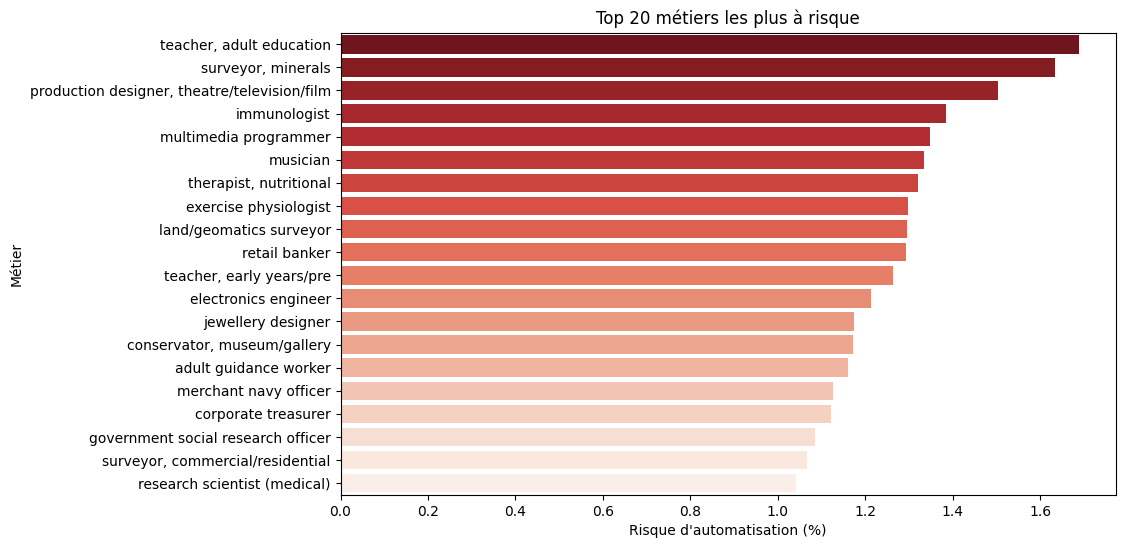

In [12]:
# Moyenne du risque par métier
top_jobs = df_small.groupby("Job_Title")["Automation_Risk_%"].mean().sort_values(ascending=False).head(20)

print("Top 20 métiers les plus à risque :")
print(top_jobs)

# Visualisation
plt.figure(figsize=(10,6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="Reds_r")
plt.xlabel("Risque d'automatisation (%)")
plt.ylabel("Métier")
plt.title("Top 20 métiers les plus à risque")
plt.show()


In [13]:
# Train Random Forest for comparison
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics for Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Performance:
RMSE: 0.0815
MAE: 0.0479
R² Score: 0.9938


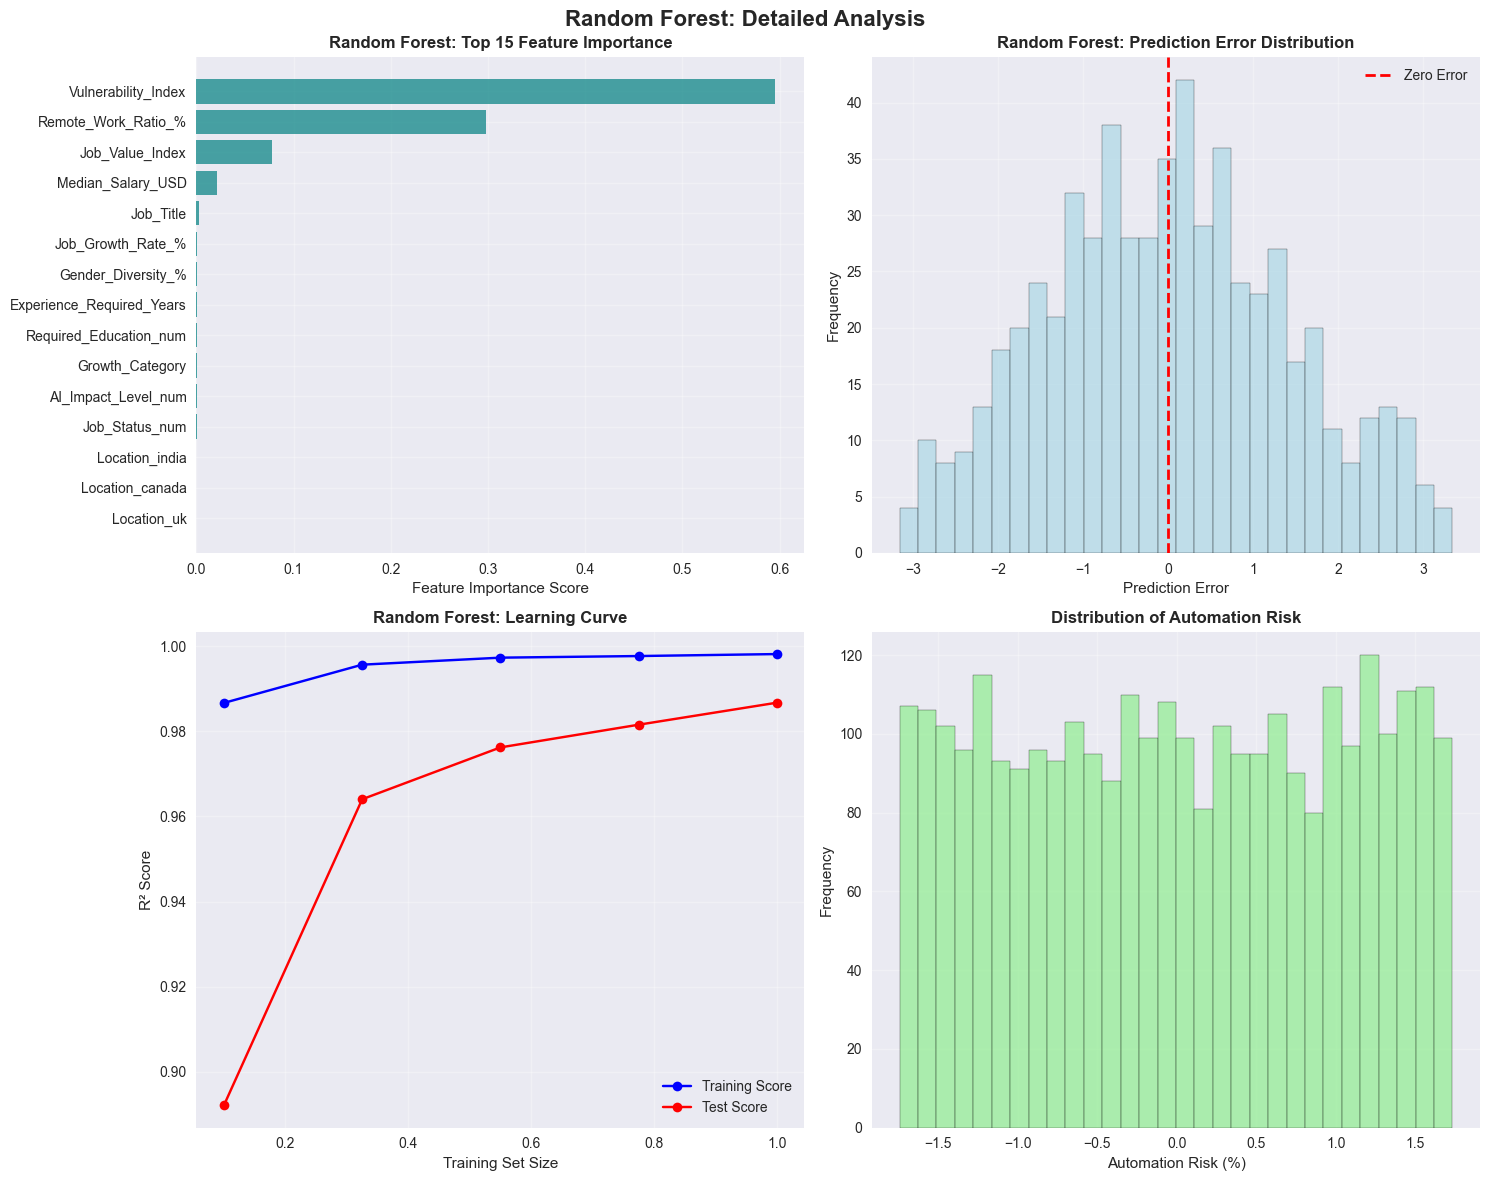

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Random Forest: Detailed Analysis', fontsize=16, fontweight='bold')
# 5.1 Random Forest Feature Importance (Detailed)
ax1 = axes[0, 0]
feature_imp_rf_detailed = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

ax1.barh(feature_imp_rf_detailed['feature'], feature_imp_rf_detailed['importance'], color='teal', alpha=0.7)
ax1.set_xlabel('Feature Importance Score')
ax1.set_title('Random Forest: Top 15 Feature Importance', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 5.2 Prediction Error Distribution
ax2 = axes[0, 1]
errors_rf = y_test - y_pred_rf
ax2.hist(errors_rf, bins=30, alpha=0.7, color='lightblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.set_xlabel('Prediction Error')
ax2.set_ylabel('Frequency')
ax2.set_title('Random Forest: Prediction Error Distribution', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 5.3 Learning Curve (Simplified)
ax3 = axes[1, 0]
train_sizes = np.linspace(0.1, 1.0, 5)
train_scores = []
test_scores = []

for size in train_sizes:
    n_samples = int(size * len(X_train))
    
    rf_temp = RandomForestRegressor(n_estimators=50, random_state=42)
    rf_temp.fit(X_train[:n_samples], y_train[:n_samples])
    
    train_score = rf_temp.score(X_train[:n_samples], y_train[:n_samples])
    test_score = rf_temp.score(X_test, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)

ax3.plot(train_sizes, train_scores, 'o-', color='blue', label='Training Score')
ax3.plot(train_sizes, test_scores, 'o-', color='red', label='Test Score')
ax3.set_xlabel('Training Set Size')
ax3.set_ylabel('R² Score')
ax3.set_title('Random Forest: Learning Curve', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 5.4 Automation Risk by Job Category (if available)
ax4 = axes[1, 1]
if 'Industry' in df_small.columns:
    industry_risk = df_small.groupby('Industry')[target].mean().sort_values(ascending=False).head(10)
    ax4.barh(range(len(industry_risk)), industry_risk.values, color='coral', alpha=0.7)
    ax4.set_yticks(range(len(industry_risk)))
    ax4.set_yticklabels(industry_risk.index)
    ax4.set_xlabel('Average Automation Risk (%)')
    ax4.set_title('Top 10 Industries by Automation Risk', fontweight='bold')
else:
    # Alternative: Show risk distribution
    ax4.hist(y, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    ax4.set_xlabel('Automation Risk (%)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Distribution of Automation Risk', fontweight='bold')

ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# **XGboost**

In [14]:
# Set style for better visuals
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the prepared data
df = df_small
print(f"Dataset shape: {df.shape}")
target = "Automation_Risk_%"
# Separate features and target
X = df.drop(columns=[target])
y = df[target]

Dataset shape: (3000, 29)


In [15]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {categorical_cols}")
print(f"Numerical features: {len(numerical_cols)}")
print(f"Target variable: {target}")

# Encode categorical variables
X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"Encoded features shape: {X_encoded.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=df['Growth_Category'] if 'Growth_Category' in df.columns else y
)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Categorical features: ['Job_Title', 'Growth_Category']
Numerical features: 26
Target variable: Automation_Risk_%
Encoded features shape: (3000, 28)
Training set: (2400, 28)
Test set: (600, 28)


In [16]:
# Convert to DMatrix for XGBoost (optional but can improve performance)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'alpha': 0.1,
    'lambda': 1.0,
    'random_state': 42
}
# Initialize and train XGBoost
xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

In [17]:
# Calculate metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")

XGBoost Performance:
RMSE: 0.0983
MAE: 0.0672
R² Score: 0.9903


COMPARISON

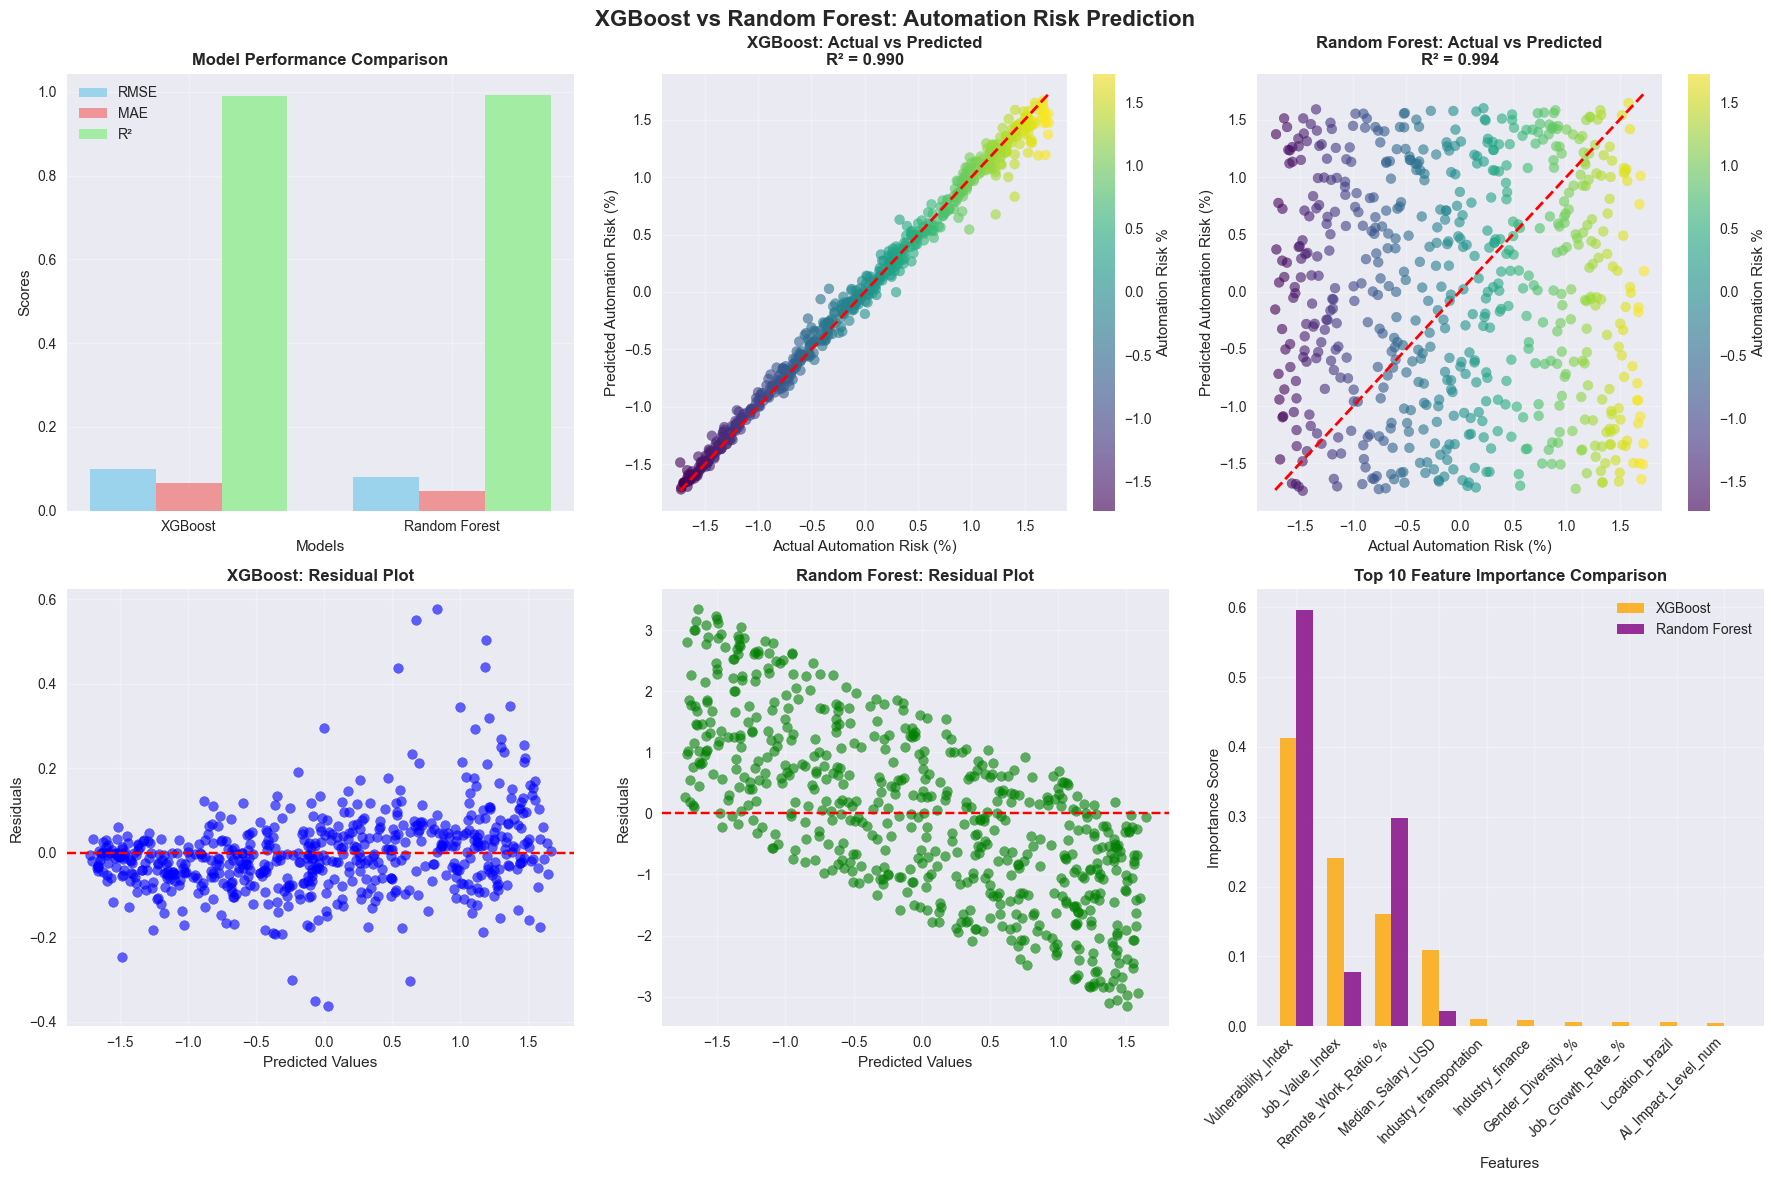

In [18]:
# Create comparison visuals
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('XGBoost vs Random Forest: Automation Risk Prediction', fontsize=16, fontweight='bold')

# 3.1 Performance Metrics Comparison
metrics_comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest'],
    'RMSE': [rmse_xgb, rmse_rf],
    'MAE': [mae_xgb, mae_rf],
    'R²': [r2_xgb, r2_rf]
})

ax1 = axes[0, 0]
x_pos = np.arange(len(metrics_comparison))
width = 0.25

ax1.bar(x_pos - width, metrics_comparison['RMSE'], width, label='RMSE', alpha=0.8, color='skyblue')
ax1.bar(x_pos, metrics_comparison['MAE'], width, label='MAE', alpha=0.8, color='lightcoral')
ax1.bar(x_pos + width, metrics_comparison['R²'], width, label='R²', alpha=0.8, color='lightgreen')

ax1.set_xlabel('Models')
ax1.set_ylabel('Scores')
ax1.set_title('Model Performance Comparison', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_comparison['Model'])
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3.2 Actual vs Predicted - XGBoost
ax2 = axes[0, 1]
scatter1 = ax2.scatter(y_test, y_pred_xgb, alpha=0.6, c=y_test, cmap='viridis', s=50)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Automation Risk (%)')
ax2.set_ylabel('Predicted Automation Risk (%)')
ax2.set_title(f'XGBoost: Actual vs Predicted\nR² = {r2_xgb:.3f}', fontweight='bold')
plt.colorbar(scatter1, ax=ax2, label='Automation Risk %')
ax2.grid(True, alpha=0.3)

# 3.3 Actual vs Predicted - Random Forest
ax3 = axes[0, 2]
scatter2 = ax3.scatter(y_test, y_pred_rf, alpha=0.6, c=y_test, cmap='viridis', s=50)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_xlabel('Actual Automation Risk (%)')
ax3.set_ylabel('Predicted Automation Risk (%)')
ax3.set_title(f'Random Forest: Actual vs Predicted\nR² = {r2_rf:.3f}', fontweight='bold')
plt.colorbar(scatter2, ax=ax3, label='Automation Risk %')
ax3.grid(True, alpha=0.3)

# 3.4 Residual Plot - XGBoost
ax4 = axes[1, 0]
residuals_xgb = y_test - y_pred_xgb
ax4.scatter(y_pred_xgb, residuals_xgb, alpha=0.6, color='blue')
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_xlabel('Predicted Values')
ax4.set_ylabel('Residuals')
ax4.set_title('XGBoost: Residual Plot', fontweight='bold')
ax4.grid(True, alpha=0.3)

# 3.5 Residual Plot - Random Forest
ax5 = axes[1, 1]
residuals_rf = y_test - y_pred_rf
ax5.scatter(y_pred_rf, residuals_rf, alpha=0.6, color='green')
ax5.axhline(y=0, color='red', linestyle='--')
ax5.set_xlabel('Predicted Values')
ax5.set_ylabel('Residuals')
ax5.set_title('Random Forest: Residual Plot', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 3.6 Feature Importance - Combined
ax6 = axes[1, 2]

# Get feature importances
feature_importance_xgb = xgb_model.feature_importances_
feature_importance_rf = rf_model.feature_importances_

# Create DataFrame for comparison
importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'XGBoost': feature_importance_xgb,
    'RandomForest': feature_importance_rf
})

# Sort by XGBoost importance and take top 10
importance_df = importance_df.sort_values('XGBoost', ascending=False).head(10)

x = np.arange(len(importance_df))
width = 0.35

ax6.bar(x - width/2, importance_df['XGBoost'], width, label='XGBoost', alpha=0.8, color='orange')
ax6.bar(x + width/2, importance_df['RandomForest'], width, label='Random Forest', alpha=0.8, color='purple')

ax6.set_xlabel('Features')
ax6.set_ylabel('Importance Score')
ax6.set_title('Top 10 Feature Importance Comparison', fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(importance_df['Feature'], rotation=45, ha='right')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



6. CROSS-VALIDATION RESULTS
XGBoost Cross-Validation R²: 0.9904 (+/- 0.0029)
Random Forest Cross-Validation R²: 0.9876 (+/- 0.0098)


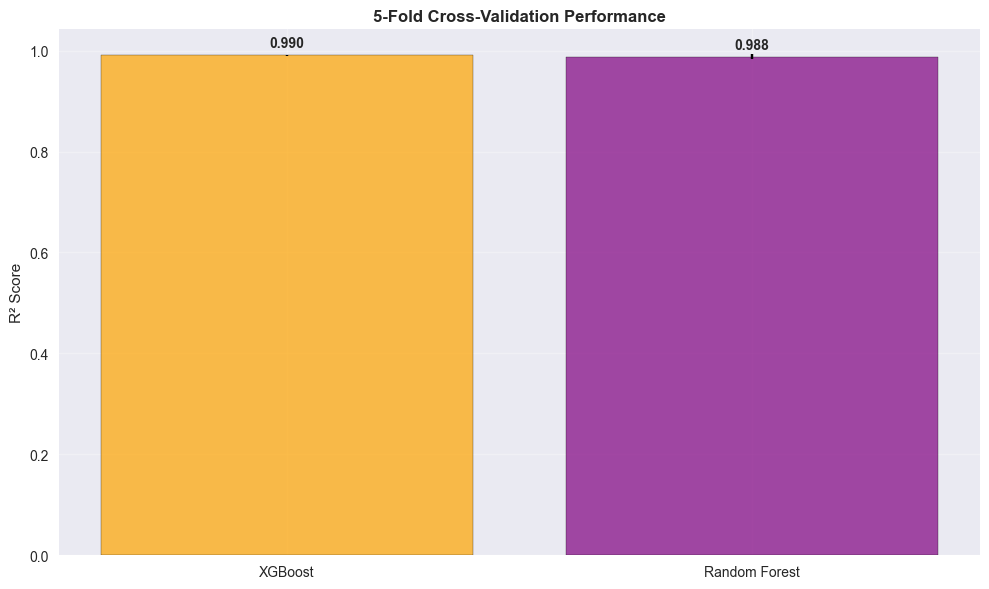


7. FINAL RESULTS SUMMARY
       Metric  XGBoost  Random Forest
0        RMSE   0.0983         0.0815
1         MAE   0.0672         0.0479
2          R²   0.9903         0.9938
3  CV R² Mean   0.9904         0.9876
4   CV R² Std   0.0015         0.0049

🎯 BEST MODEL: Random Forest
📈 Improvement over other model: 0.35%


In [ ]:


print("CROSS-VALIDATION RESULTS")
# Perform cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

print(f"XGBoost Cross-Validation R²: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")
print(f"Random Forest Cross-Validation R²: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")

# Cross-validation visualization
plt.figure(figsize=(10, 6))
models = ['XGBoost', 'Random Forest']
cv_means = [cv_scores_xgb.mean(), cv_scores_rf.mean()]
cv_stds = [cv_scores_xgb.std(), cv_scores_rf.std()]

bars = plt.bar(models, cv_means, yerr=cv_stds, capsize=10, alpha=0.7, 
               color=['orange', 'purple'], edgecolor='black')

plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation Performance', fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



print("SUMMARY")
# Create final summary
results_summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²', 'CV R² Mean', 'CV R² Std'],
    'XGBoost': [rmse_xgb, mae_xgb, r2_xgb, cv_scores_xgb.mean(), cv_scores_xgb.std()],
    'Random Forest': [rmse_rf, mae_rf, r2_rf, cv_scores_rf.mean(), cv_scores_rf.std()]
})

print(results_summary.round(4))

# Determine best model
if r2_xgb > r2_rf:
    best_model = "XGBoost"
    improvement = ((r2_xgb - r2_rf) / r2_rf) * 100
else:
    best_model = "Random Forest"
    improvement = ((r2_rf - r2_xgb) / r2_xgb) * 100

print(f"\n🎯 BEST MODEL: {best_model}")
print(f"📈 Improvement over other model: {abs(improvement):.2f}%")
